#### Task 1: Exploratory Data Analysis (EDA):
1.	Load the dataset and perform basic data exploration.
2.	Examine the distribution of features using histograms, box plots, or density plots.
3.	Investigate correlations between features to understand relationships within the data.
#### Task 2: Dimensionality Reduction with PCA:
1.	Standardize the features to ensure they have a mean of 0 and a standard deviation of Implement PCA to reduce the dimensionality of the dataset.
2.	Determine the optimal number of principal components using techniques like scree plot or cumulative explained variance.
3.	Transform the original dataset into the principal components.
#### Task 3: Clustering with Original Data:
1.	Apply a clustering algorithm (e.g., K-means) to the original dataset.
2.	Visualize the clustering results using appropriate plots.
3.	Evaluate the clustering performance using metrics such as silhouette score or Davies–Bouldin index.
#### Task 4: Clustering with PCA Data:
1.	Apply the same clustering algorithm to the PCA-transformed dataset.
2.	Visualize the clustering results obtained from PCA-transformed data.
3.	Compare the clustering results from PCA-transformed data with those from the original dataset.
#### Task 5: Comparison and Analysis:
1.	Compare the clustering results obtained from the original dataset and PCA-transformed data.
2.	Discuss any similarities or differences observed in the clustering results.
3.	Reflect on the impact of dimensionality reduction on clustering performance.
4.	Analyze the trade-offs between using PCA and clustering directly on the original dataset.
#### Task 6: Conclusion and Insights

1.	Summarize the key findings and insights from the assignment.
2.	Discuss the practical implications of using PCA and clustering in data analysis.
3.	Provide recommendations for when to use each technique based on the analysis conducted.


# Task 1: Exploratory Data Analysis (EDA):

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

In [2]:
# loading dataset
df = pd.read_csv("wine.csv")
df

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


In [3]:
df.head()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [5]:
df.tail()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.7,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.3,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.2,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.3,0.60,1.62,840
177,3,14.13,4.10,2.74,24.5,96,2.05,0.76,0.56,1.35,9.2,0.61,1.60,560


In [6]:
# Shape of the data
df.shape

(178, 14)

In [7]:
# Information of the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [8]:
# Statistical analysis of the data
df.describe()

,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,1.938202,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.775035,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,1.000000,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,1.000000,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,2.000000,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,3.000000,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,3.000000,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


Different features have different ranges of values.
Hence scaling is required before PCA.

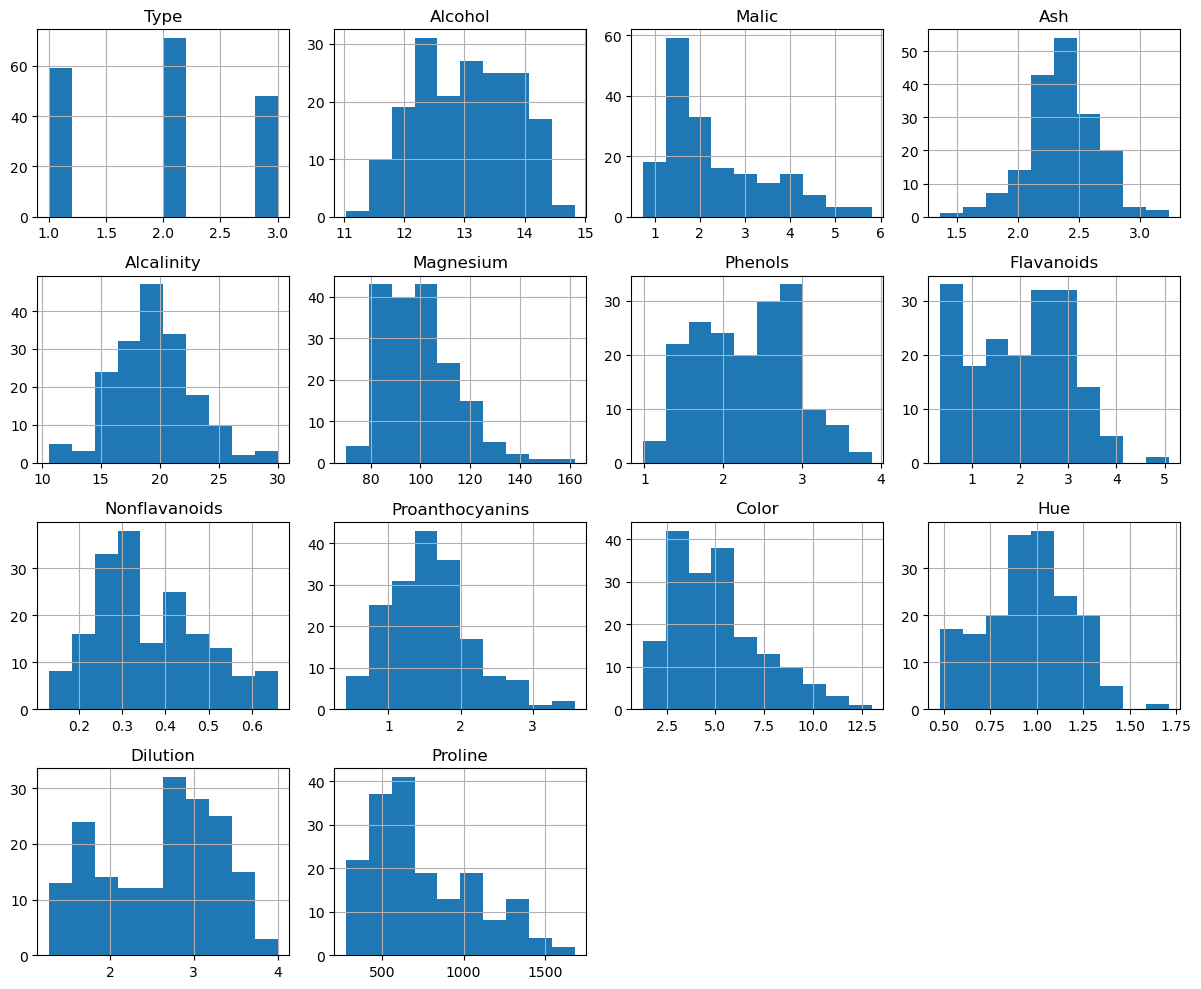

In [10]:
# Histogram
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

Features show different distributions.
Some features are skewed.

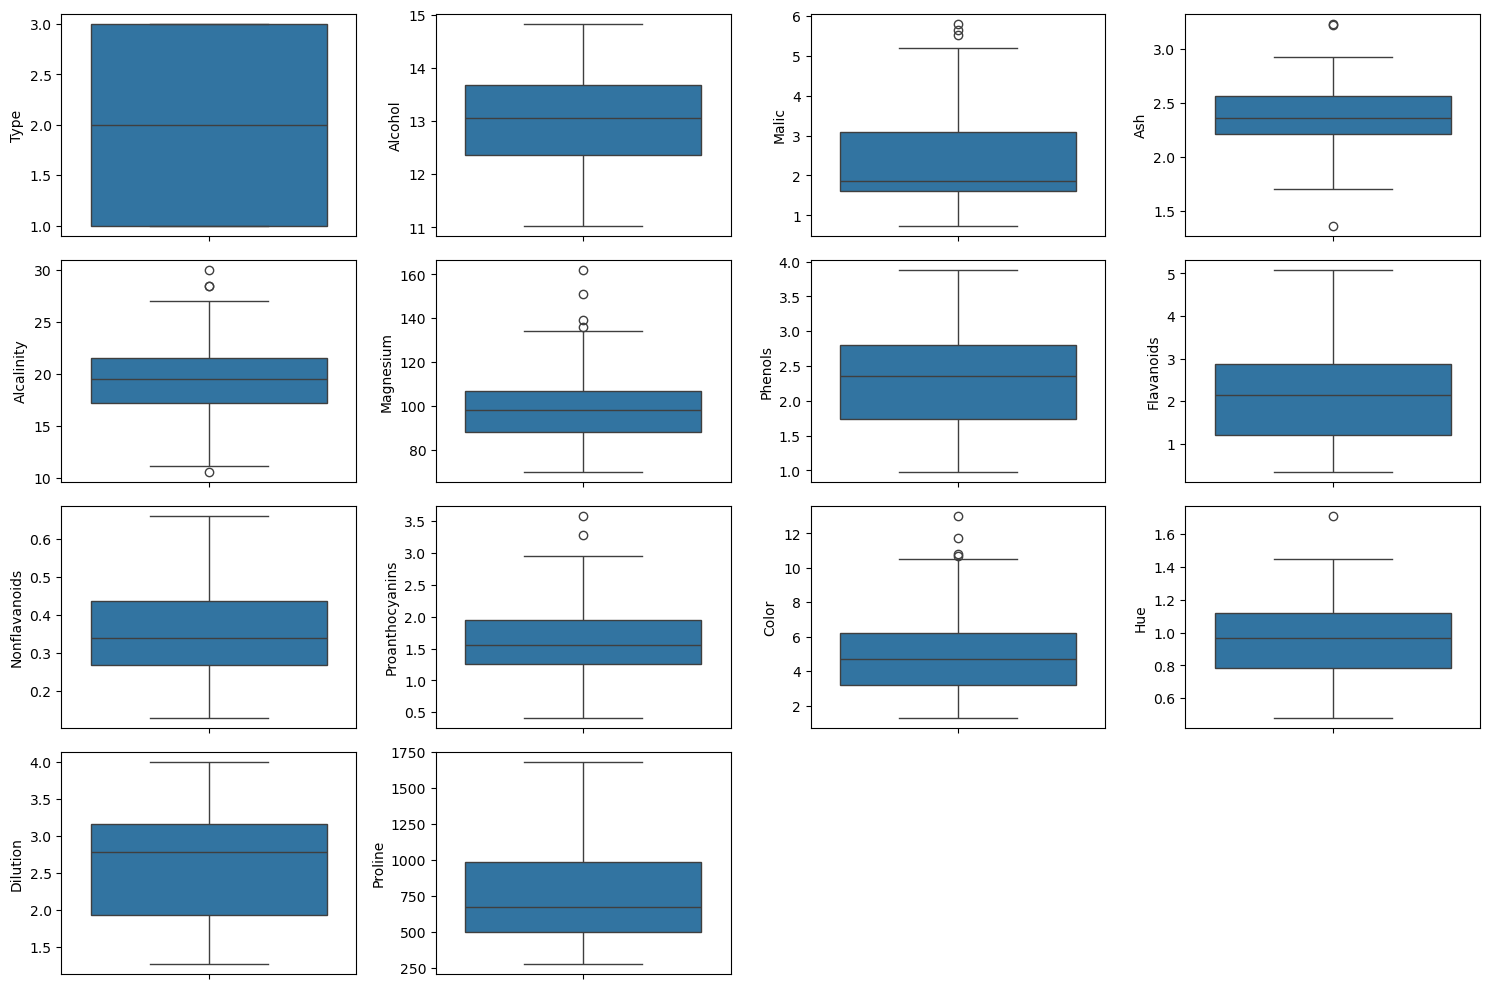

In [11]:
# Boxplot
plt.figure(figsize=(15,10))

for i,col in enumerate(df.columns):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()

Some outliers are present in the dataset.

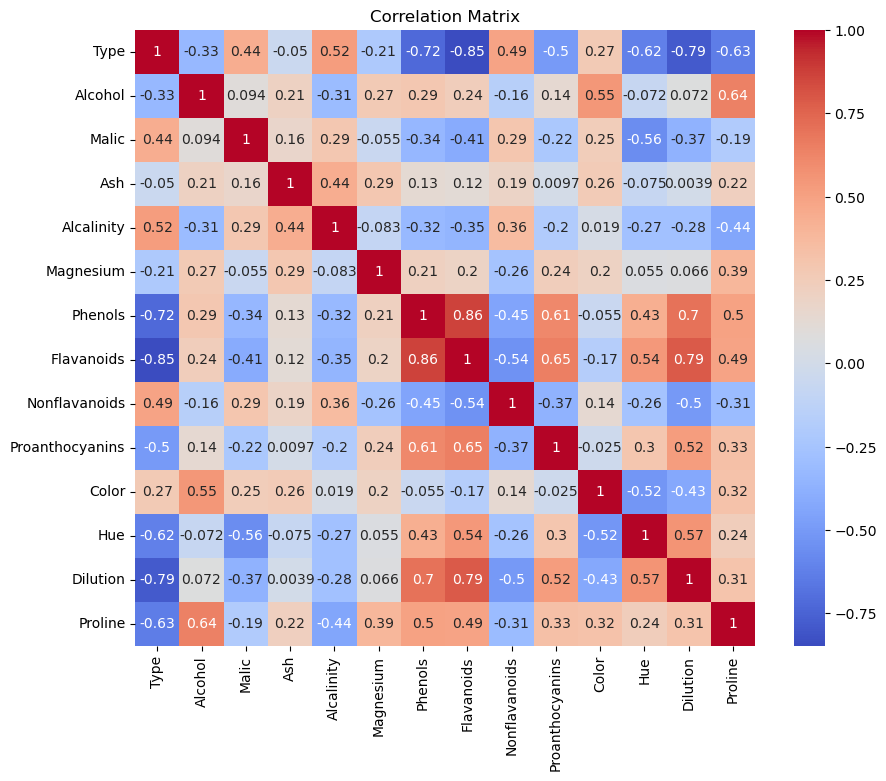

In [12]:
# corelation heatmap
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

Some variables are positively correlated while some are negatively correlated.

# Task 2: Dimensionality Reduction with PCA:

In [13]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

Data is standardized with mean = 0 and standard deviation = 1.

In [14]:
# Applying pca
pca = PCA()

pca_data = pca.fit_transform(scaled_data)

In [15]:
pca.explained_variance_ratio_

array([0.39542486, 0.17836259, 0.10329102, 0.06627984, 0.06267875,
       0.0480556 , 0.03955707, 0.02500244, 0.02103871, 0.01873615,
       0.01613203, 0.01205691, 0.00925458, 0.00412945])

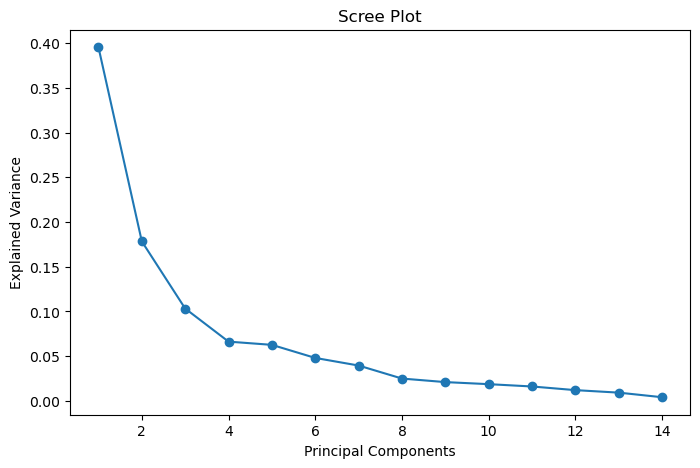

In [16]:
# Scree plot
plt.figure(figsize=(8,5))

plt.plot(
    range(1,len(pca.explained_variance_ratio_)+1),
    pca.explained_variance_ratio_,
    marker='o'
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Scree Plot")
plt.show()

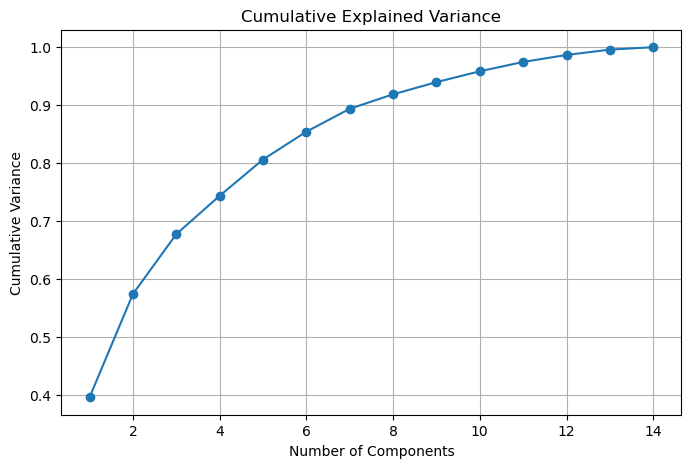

In [17]:
# Commulative Explained variance
cum_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,len(cum_var)+1),
    cum_var,
    marker='o'
)

plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance")
plt.title("Cumulative Explained Variance")
plt.grid()
plt.show()

First few principal components explain most of the variance.

In [18]:
# Principle components
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(
    pca_data,
    columns=['PC1','PC2']
)

pca_df.head()

,PC1,PC2
0,-3.522934,1.453098
1,-2.528858,-0.330019
2,-2.785029,1.036936
3,-3.922588,2.768210
4,-1.407511,0.867773


# Task 3: Clustering with Original Data

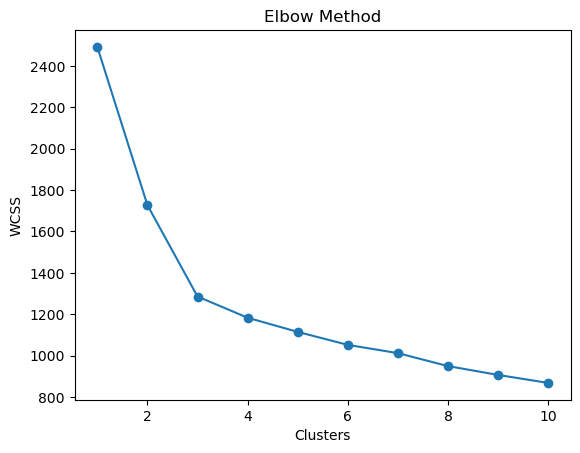

In [20]:
# Elbow method 
import warnings
warnings.filterwarnings('ignore')

wcss = []

for i in range(1,11):
    km = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    km.fit(scaled_data)
    wcss.append(km.inertia_)

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

The elbow point suggests the optimal number of clusters.

In [21]:
# K-Means clustering
kmeans_original = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters_original = kmeans_original.fit_predict(scaled_data)

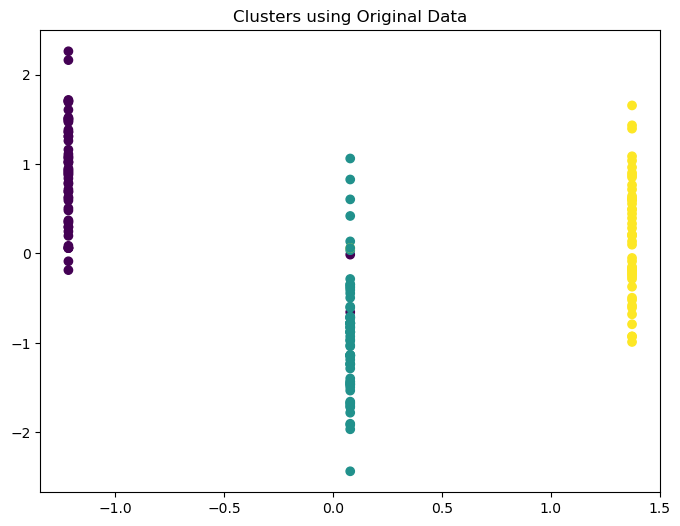

In [22]:
# Cluster visualization
plt.figure(figsize=(8,6))

plt.scatter(
    scaled_data[:,0],
    scaled_data[:,1],
    c=clusters_original,
    cmap='viridis'
)

plt.title("Clusters using Original Data")
plt.show()

In [23]:
# Silhouete score
sil_score_original = silhouette_score(
    scaled_data,
    clusters_original
)

print("Silhouette Score:",sil_score_original)

Silhouette Score: 0.30773604383565206


In [24]:
# Devis bouldin score
db_original = davies_bouldin_score(
    scaled_data,
    clusters_original
)

print("Davies Bouldin Score:",db_original)

Davies Bouldin Score: 1.3163957434114109


# Task 4: Clustering with PCA Data

In [25]:
# Applying k_Means
kmeans_pca = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters_pca = kmeans_pca.fit_predict(pca_df)

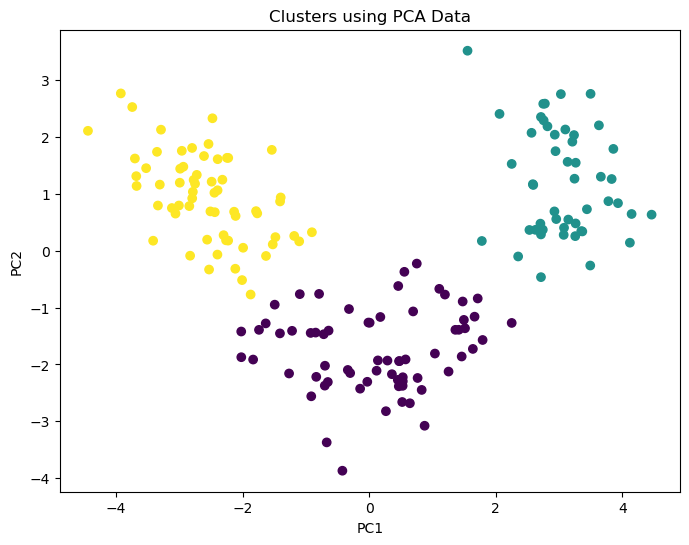

In [26]:
# Visualizations
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=clusters_pca,
    cmap='viridis'
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters using PCA Data")
plt.show()

In [27]:
# Silhouette score
sil_score_pca = silhouette_score(
    pca_df,
    clusters_pca
)

print("Silhouette Score:",sil_score_pca)

Silhouette Score: 0.6024415520362845


In [28]:
# Davies bouldin score
db_pca = davies_bouldin_score(
    pca_df,
    clusters_pca
)

print("Davies Bouldin Score:",db_pca)

Davies Bouldin Score: 0.5397078562575711


# Task 5: Comparison and Analysis

In [29]:
# omparison table
comparison = pd.DataFrame({
    'Metric':['Silhouette Score',
              'Davies Bouldin Score'],
    'Original Data':[sil_score_original,
                     db_original],
    'PCA Data':[sil_score_pca,
                db_pca]
})

comparison

,Metric,Original Data,PCA Data
0,Silhouette Score,0.307736,0.602442
1,Davies Bouldin Score,1.316396,0.539708


### Analysis
1. PCA reduced the dimensionality of the dataset.
2. Clustering became easier to visualize.
3. PCA retained most important information.
4. Silhouette score and Davies-Bouldin score were compared.
5. PCA may improve clustering performance by removing noise.

# Task 6: Conclusion and Insights

#### Conclusion

1. PCA was applied to reduce dimensionality of the wine dataset.
2. The first two principal components captured most of the information.
3. K-Means clustering was performed on both original and PCA-transformed data.
4. PCA made cluster visualization easier.
5. Clustering performance was evaluated using Silhouette Score and Davies-Bouldin Score.
6. PCA helps reduce complexity while preserving important information.
7. Therefore PCA is useful before clustering when the dataset contains many features.